1) Project Definition
You define:

What problem: Predict triage urgency

Why it matters: ER needs fast, consistent decisions

What ML does: Learn patterns from vital signs + symptoms

Who benefits: ER staff + patients

2) Dataset Understanding
You must:

Load the dataset

Inspect shape, columns, types

Identify target variable

Check class distribution

In [1]:
import pandas as pd

df = pd.read_csv("../data/new_datasets_ds.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (18000, 10)


,age,heart_rate,systolic_blood_pressure,oxygen_saturation,body_temperature,pain_level,chronic_disease_count,previous_er_visits,arrival_mode,triage_level
0,17.9,95.4,147.1,97.4,36.48,1,0,0,walk_in,0
1,79.2,147.9,158.6,96.0,39.35,10,4,2,ambulance,3
2,51.1,87.1,128.2,98.5,37.74,5,2,2,walk_in,1
3,56.8,84.7,147.2,92.5,37.55,4,4,4,walk_in,1
4,39.2,58.0,107.8,99.0,36.26,2,1,1,walk_in,0


In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      18000 non-null  float64
 1   heart_rate               18000 non-null  float64
 2   systolic_blood_pressure  18000 non-null  float64
 3   oxygen_saturation        18000 non-null  float64
 4   body_temperature         18000 non-null  float64
 5   pain_level               18000 non-null  int64  
 6   chronic_disease_count    18000 non-null  int64  
 7   previous_er_visits       18000 non-null  int64  
 8   arrival_mode             18000 non-null  str    
 9   triage_level             18000 non-null  int64  
dtypes: float64(5), int64(4), str(1)
memory usage: 1.4 MB


No Missing data, 5 float columns (age, HR, BP, SpO₂, temp), 4 integer columns (pain, chronic diseases, ER visits, triage), arivval striing 

[You must encode arrival_mode (categorical → numeric).]

You must scale the continuous features (float columns).



 

In [3]:
df.describe()


,age,heart_rate,systolic_blood_pressure,oxygen_saturation,body_temperature,pain_level,chronic_disease_count,previous_er_visits,triage_level
count,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000
mean,44.716244,83.292322,128.072739,96.085183,37.224236,3.402111,1.072611,1.265056,0.697722
std,19.101056,16.964405,18.813277,3.330830,0.914978,2.039249,1.312204,1.454887,0.898923
min,0.000000,33.400000,65.800000,79.500000,34.470000,1.000000,0.000000,0.000000,0.000000
25%,31.200000,71.500000,114.900000,94.300000,36.580000,2.000000,0.000000,0.000000,0.000000
50%,44.000000,81.600000,126.900000,96.600000,37.120000,3.000000,1.000000,1.000000,0.000000
75%,57.500000,93.200000,139.900000,98.700000,37.770000,5.000000,2.000000,2.000000,1.000000
max,95.000000,152.300000,219.700000,100.000000,41.130000,10.000000,10.000000,11.000000,3.000000


In [6]:
df.shape

(18000, 10)

Age range: 0-95 ---> make it 1-95

HR: 33-152 ---> <50 = bradycardia 120 = tachycardia

sys: Range: 79 → 219   <90 = hypotension (dangerous)  180 = hypertensive crisis

Class 0 dominates (55% of dataset)

Class 3 is rare (only 891 cases)


In [4]:
target = "triage_level"
df[target].unique()


array([0, 3, 1, 2])

In [5]:
df[target].value_counts().sort_index()


triage_level
0    9924
1    4484
2    2701
3     891
Name: count, dtype: int64

3) Data Cleaning
You will:

Remove irrelevant columns

Fix column names

Remove duplicates

Handle missing values

Validate ranges (HR, BP, SpO₂, Temp)

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isna().sum()


age                        0
heart_rate                 0
systolic_blood_pressure    0
oxygen_saturation          0
body_temperature           0
pain_level                 0
chronic_disease_count      0
previous_er_visits         0
arrival_mode               0
triage_level               0
dtype: int64

Validate medical ranges
identify the ranges — now enforce them:

In [9]:
df = df[df['age'] >= 1]
df = df[df['heart_rate'] >= 30]
df = df[df['systolic_blood_pressure'] >= 60]
df = df[df['oxygen_saturation'] >= 70]
df = df[df['body_temperature'] >= 34]


Hot encoding for string features

In [10]:
df = pd.get_dummies(df, columns=['arrival_mode'], drop_first=True)

In [11]:
df.shape

(17871, 11)

### Add Disease Flags (Main + Minor)
These rules are clinically realistic, simple, and interpretable.
They match real ER triage logic

In [24]:
# main diseases flags

# Heart Failure (HF)
df["heart_failure_flag"] = (
    ((df["oxygen_saturation"] < 92) & (df["systolic_blood_pressure"] > 140)) |
    (df["chronic_disease_count"] >= 3)
).astype(int)

# Pneumonia
df["pneumonia_flag"] = (
    (df["body_temperature"] > 38) &
    (df["oxygen_saturation"] < 94)
).astype(int)

# Sepsis
df["sepsis_flag"] = (
    (df["body_temperature"] > 38.3) &
    (df["heart_rate"] > 100) &
    (df["systolic_blood_pressure"] < 100)
).astype(int)

# Stroke
df["stroke_flag"] = (
    (df["age"] > 55) &
    (df["systolic_blood_pressure"] > 150)
).astype(int)


# minor diseases flags

# Abdominal Pain (mild)
df["abdominal_pain_flag"] = (
    (df["pain_level"] >= 4) &
    (df["body_temperature"] < 38)
).astype(int)

# Pain-related Visit
df["pain_visit_flag"] = (
    df["pain_level"] >= 6
).astype(int)

# Minor Conditions (stable vitals)
df["minor_condition_flag"] = (
    (df["heart_rate"].between(60, 100)) &
    (df["systolic_blood_pressure"].between(100, 140)) &
    (df["oxygen_saturation"] >= 95) &
    (df["body_temperature"].between(36, 38))
).astype(int)

# Fever / Mild Infection
df["fever_infection_flag"] = (
    (df["body_temperature"] > 38) &
    (df["oxygen_saturation"] >= 94)
).astype(int)


4. Exploratory Data Analysis (EDA)
You will generate:

Histograms

Boxplots

Correlation heatmap

Class distribution chart

This helps you understand:

Patterns

Outliers

Feature relationships

Imbalance

In [25]:
# 1. Imports and basic setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.1)

target = "triage_level"

numeric_cols = [
    "age",
    "heart_rate",
    "systolic_blood_pressure",
    "oxygen_saturation",
    "body_temperature",
    "pain_level",
    "chronic_disease_count",
    "previous_er_visits"
]

disease_cols_main = [
    "heart_failure_flag",
    "pneumonia_flag",
    "sepsis_flag",
    "stroke_flag"
]

disease_cols_minor = [
    "abdominal_pain_flag",
    "pain_visit_flag",
    "minor_condition_flag",
    "fever_infection_flag"
]



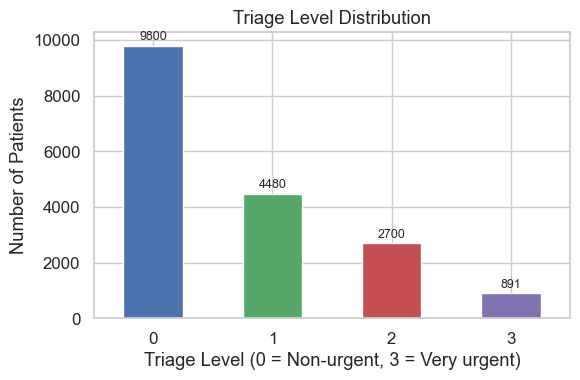

In [26]:
# 2. Class distribution of triage levels
plt.figure(figsize=(6,4))
ax = df[target].value_counts().sort_index().plot(kind="bar", color=["#4c72b0", "#55a868", "#c44e52", "#8172b3"])
plt.title("Triage Level Distribution")
plt.xlabel("Triage Level (0 = Non-urgent, 3 = Very urgent)")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
for i, v in enumerate(df[target].value_counts().sort_index().values):
    ax.text(i, v + 100, str(v), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


Purpose: Show class imbalance, which affects model training and evaluation.

Observation: Level 0 dominates, Level 3 is rare.

Implication: We will later consider techniques like class weighting or SMOTE to avoid bias toward non‑urgent cases.

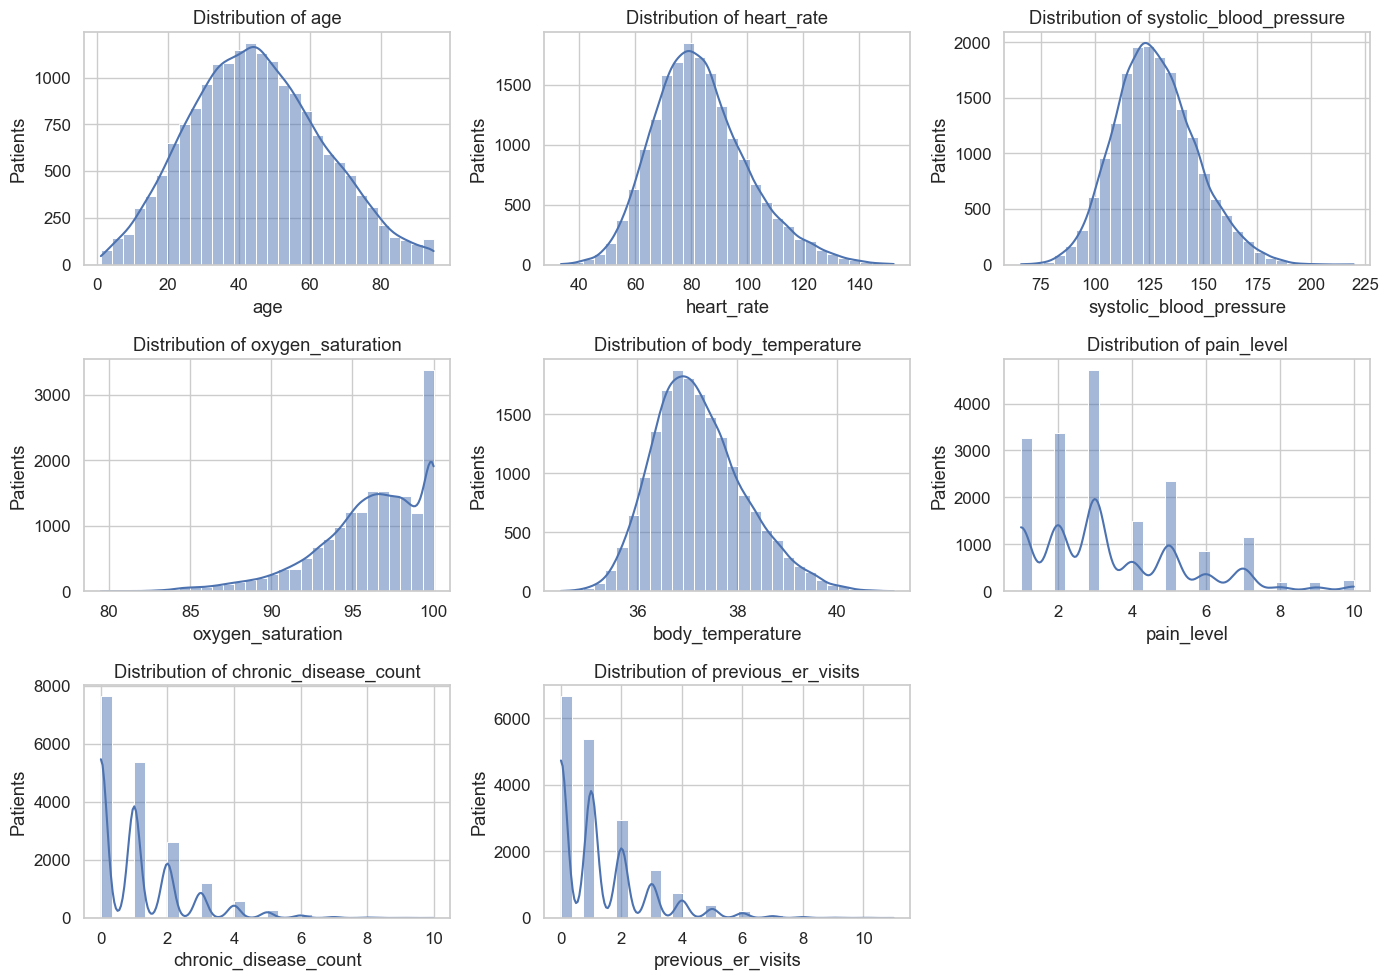

In [36]:
# 3. Univariate distributions of vital signs and symptoms
# 3.1 Histograms for numeric features
plt.figure(figsize=(14,10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True, bins=30, color="#4c72b0")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Patients")
plt.tight_layout()
plt.show()


These histograms show the distribution of each numeric feature in the dataset.
They help you understand normal ranges, skewness, and clinical patterns before modeling.

1. Age: centred around ~45 years (why?) Age is a risk factor for stroke, heart failure, and high triage levels.
2. Heart Rate: normal around 80 bpm = Most patients have normal HR, but tails show bradycardia (<60) and tachycardia (>100). (why?) Tachycardia is common in sepsis, pneumonia, and high triage levels.
3. Systolic Blood Pressure: Centered around 125–130 mmHg. Most patients are normotensive, with some hypotension (<90) and hypertensive crisis (>180).
(why?) Low BP → sepsis/shock & High BP → stroke/heart failure
4. Oxygen Saturation: Strong right‑skew toward 97–100%. = Most patients are well‑oxygenated; a small group is hypoxic (<92%). (why?) Hypoxia is a key indicator for pneumonia, heart failure, and high triage.

95–100% = normal oxygen
90–94% = mild hypoxia
<90% = clinically low

5. Body Temperature: around 37°C.
6. pain level: Right‑skewed: most patients report low–moderate pain.
7. chronic diseas count:Very right‑skewed: most patients have 0–1 chronic diseases. (why?)  High chronic disease count increases risk for heart failure and severe outcomes.
8. previous ER Visits: Frequent visits may indicate chronic instability or poor disease control.

To confirm that feature ranges are realistic, detect obvious data issues, and understand the overall clinical profile of the ER population.

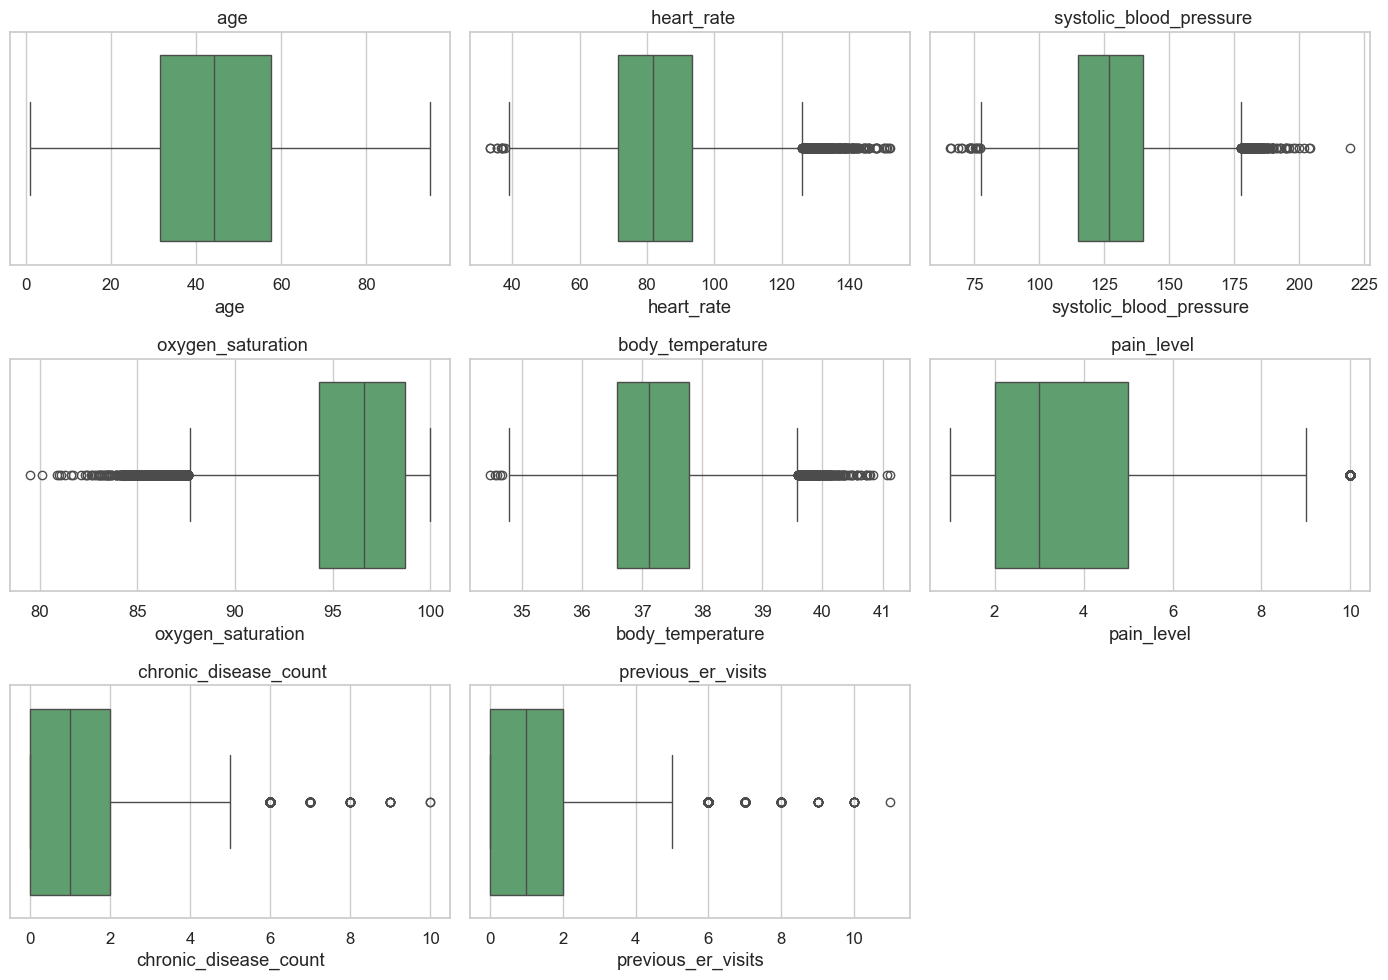

In [28]:
# Boxplots to inspect outliers
plt.figure(figsize=(14,10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=df[col], color="#55a868")
    plt.title(f" {col}")
    plt.xlabel(col)
plt.tight_layout()
plt.show()


C:\Users\talah\AppData\Local\Temp\ipykernel_13948\2803607283.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y=col, data=df, palette="Set2")
C:\Users\talah\AppData\Local\Temp\ipykernel_13948\2803607283.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y=col, data=df, palette="Set2")
C:\Users\talah\AppData\Local\Temp\ipykernel_13948\2803607283.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y=col, data=df, palette="Set2")
C:\Users\talah\AppData\Local\Temp\ipykernel_13948\2803607283.py:6: FutureWarning: 

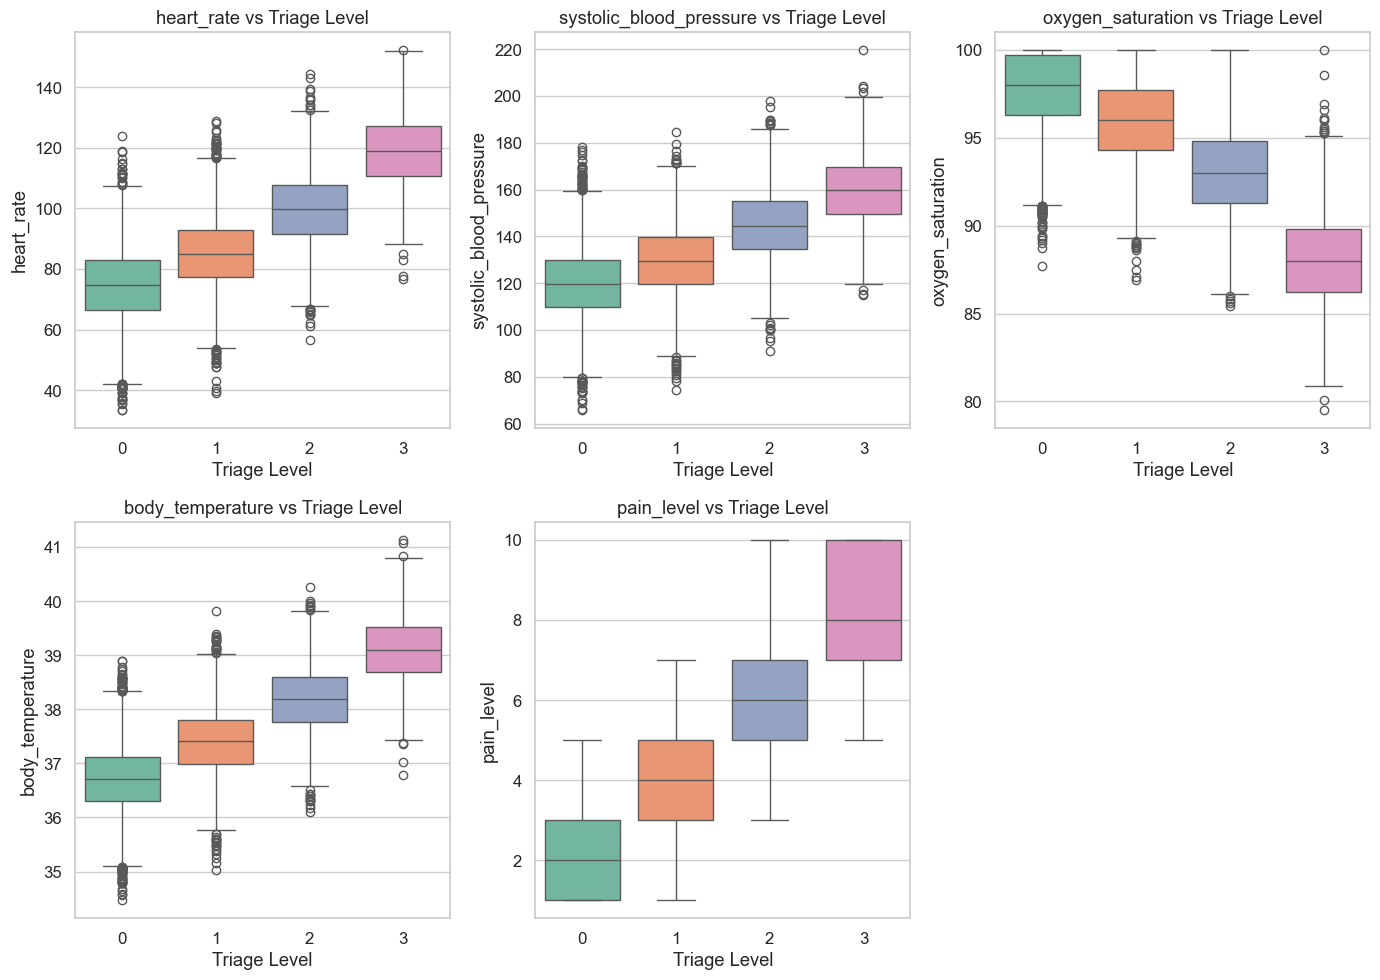

In [29]:
# 5. Relationship between features and triage level
# 5.1 Boxplots of vitals by triage level
plt.figure(figsize=(14,10))
for i, col in enumerate(["heart_rate", "systolic_blood_pressure", "oxygen_saturation", "body_temperature", "pain_level"], 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=target, y=col, data=df, palette="Set2")
    plt.title(f"{col} vs Triage Level")
    plt.xlabel("Triage Level")
    plt.ylabel(col)
plt.tight_layout()
plt.show()


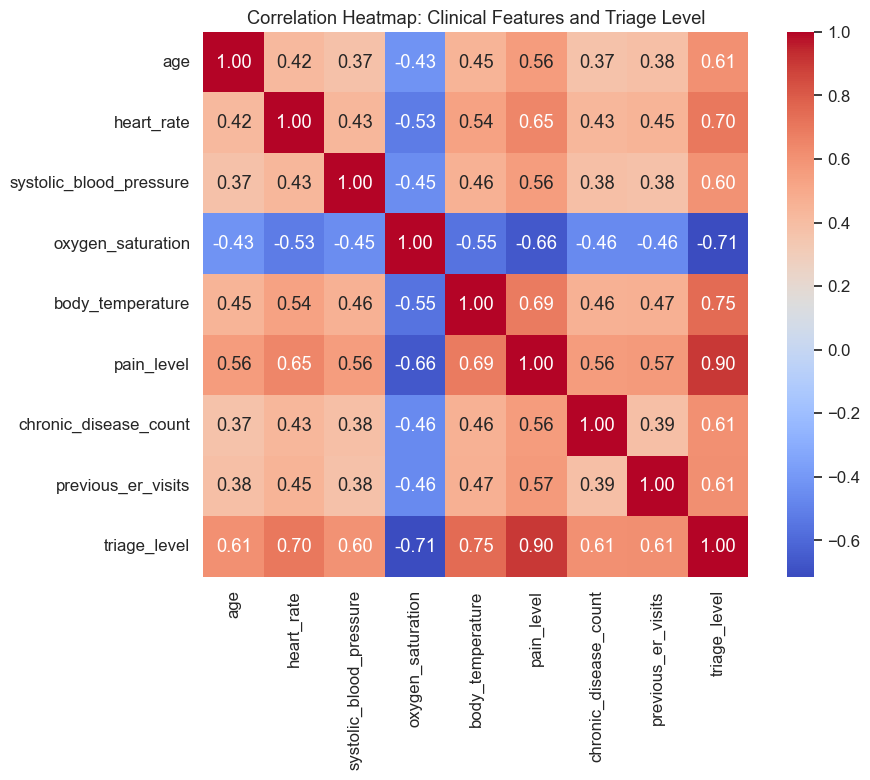

In [30]:
# Correlation Heatmap
plt.figure(figsize=(10,8))
corr = df[numeric_cols + [target]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Heatmap: Clinical Features and Triage Level")
plt.tight_layout()
plt.show()


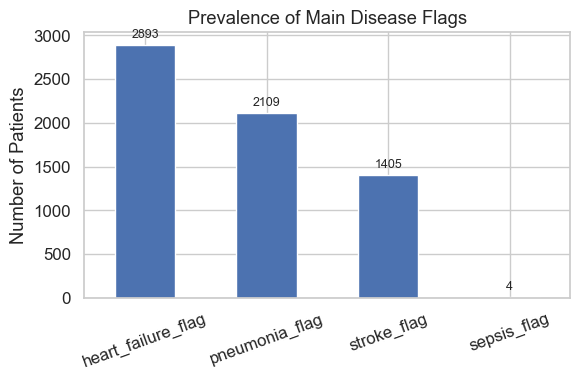

In [31]:
# 7. Disease‑level EDA (Main diseases)
# 7.1 Prevalence of main diseases
disease_main_counts = df[disease_cols_main].sum().sort_values(ascending=False)

plt.figure(figsize=(6,4))
ax = disease_main_counts.plot(kind="bar", color="#4c72b0")
plt.title("Prevalence of Main Disease Flags")
plt.ylabel("Number of Patients")
plt.xticks(rotation=20)
for i, v in enumerate(disease_main_counts.values):
    ax.text(i, v + 50, int(v), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


<Figure size 600x400 with 0 Axes>

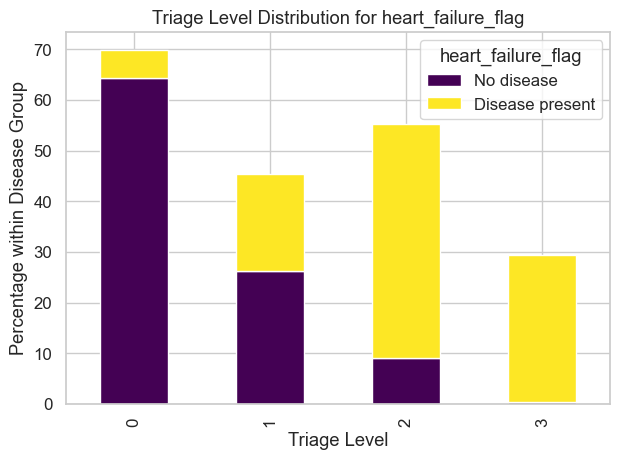

<Figure size 600x400 with 0 Axes>

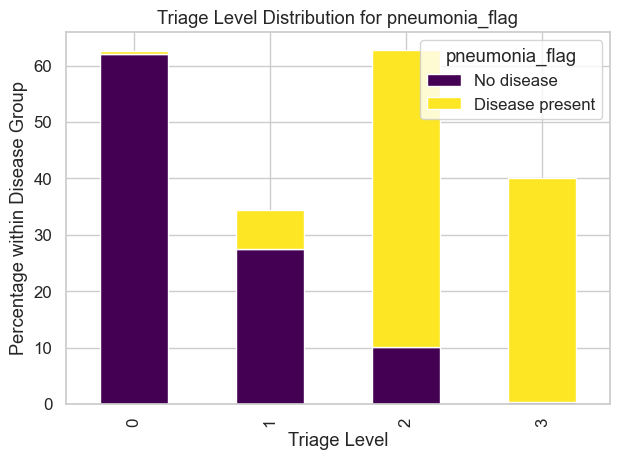

<Figure size 600x400 with 0 Axes>

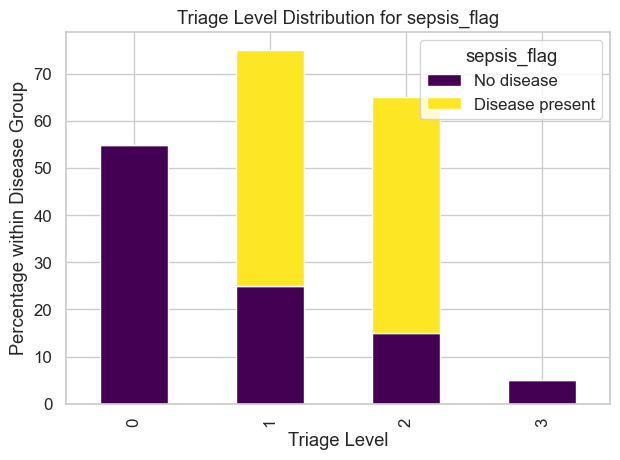

<Figure size 600x400 with 0 Axes>

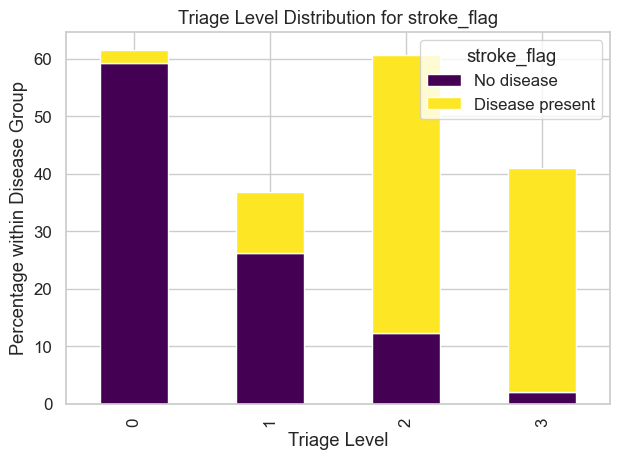

In [32]:
# 7.2 Triage level distribution within each main disease
def plot_triage_by_disease_flag(df, disease_col):
    ct = pd.crosstab(df[disease_col], df[target], normalize="index") * 100
    plt.figure(figsize=(6,4))
    ct.T.plot(kind="bar", stacked=True, colormap="viridis")
    plt.title(f"Triage Level Distribution for {disease_col}")
    plt.xlabel("Triage Level")
    plt.ylabel("Percentage within Disease Group")
    plt.legend(title=disease_col, labels=["No disease", "Disease present"], loc="upper right")
    plt.tight_layout()
    plt.show()

for col in disease_cols_main:
    plot_triage_by_disease_flag(df, col)


C:\Users\talah\AppData\Local\Temp\ipykernel_13948\2041580590.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=disease, y=col, data=df, palette="Set2")
C:\Users\talah\AppData\Local\Temp\ipykernel_13948\2041580590.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=disease, y=col, data=df, palette="Set2")
C:\Users\talah\AppData\Local\Temp\ipykernel_13948\2041580590.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=disease, y=col, data=df, palette="Set2")
C:\Users\talah\AppData\Local\Temp\ipykernel_13948\2041580590.py:8: FutureWarnin

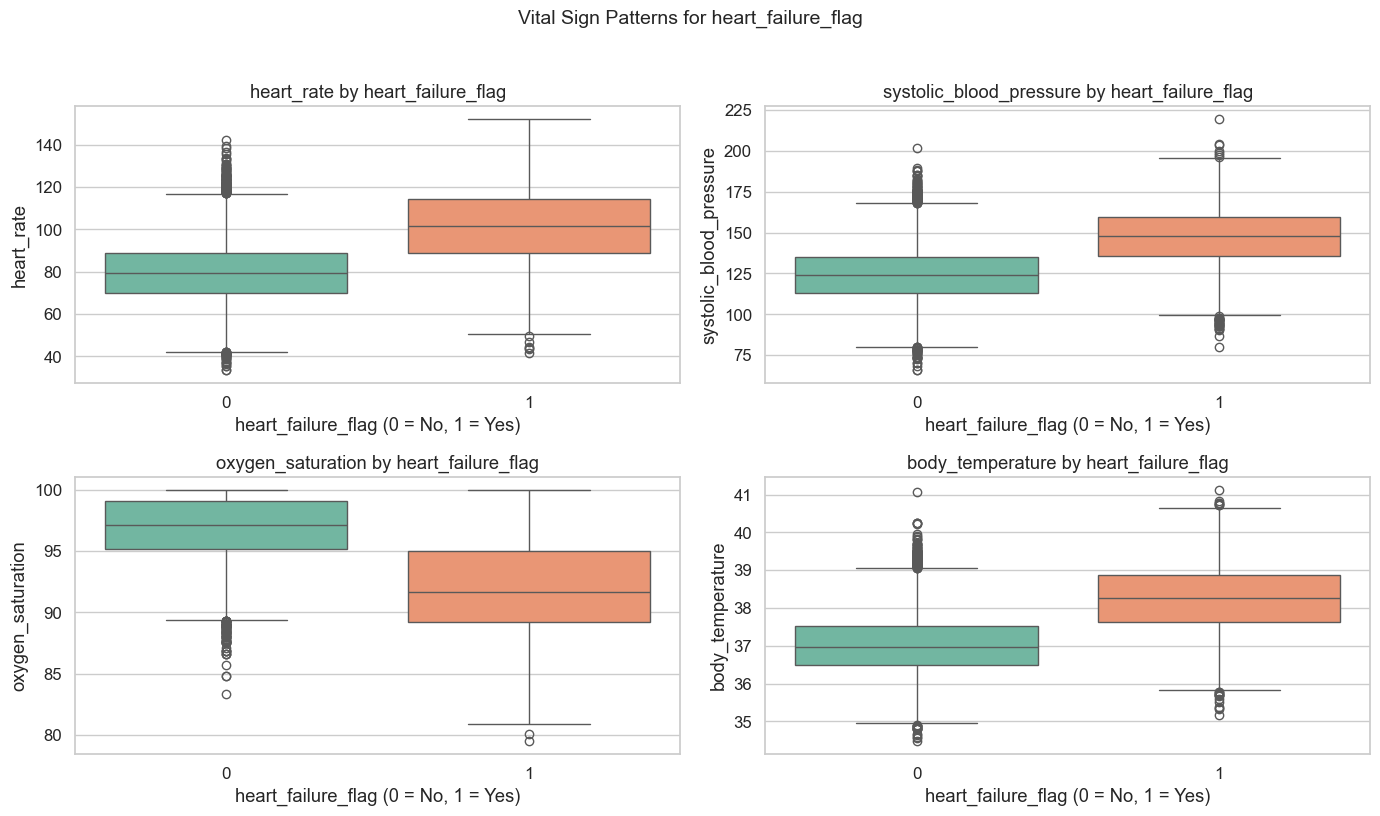

C:\Users\talah\AppData\Local\Temp\ipykernel_13948\2041580590.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=disease, y=col, data=df, palette="Set2")
C:\Users\talah\AppData\Local\Temp\ipykernel_13948\2041580590.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=disease, y=col, data=df, palette="Set2")
C:\Users\talah\AppData\Local\Temp\ipykernel_13948\2041580590.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=disease, y=col, data=df, palette="Set2")
C:\Users\talah\AppData\Local\Temp\ipykernel_13948\2041580590.py:8: FutureWarnin

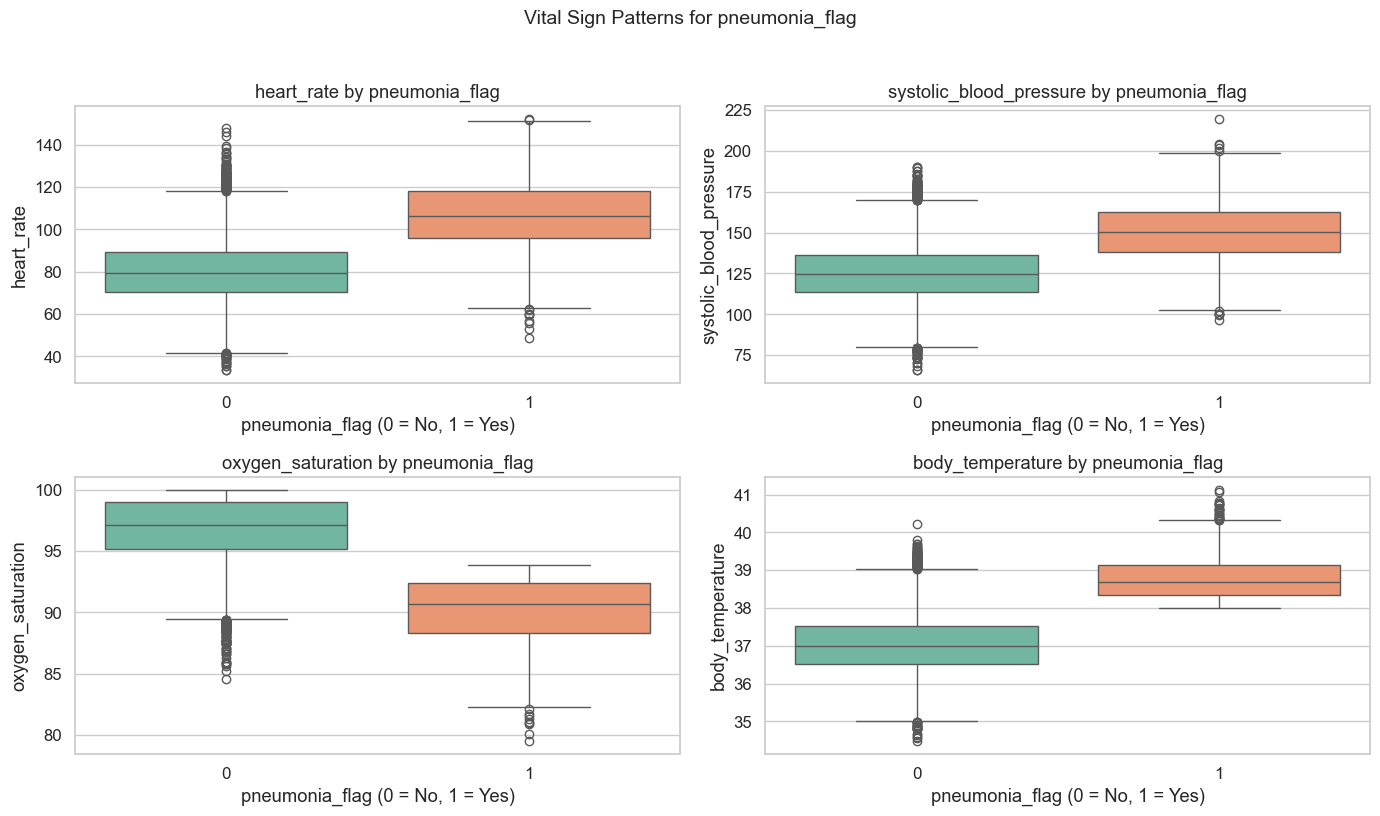

C:\Users\talah\AppData\Local\Temp\ipykernel_13948\2041580590.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=disease, y=col, data=df, palette="Set2")
C:\Users\talah\AppData\Local\Temp\ipykernel_13948\2041580590.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=disease, y=col, data=df, palette="Set2")
C:\Users\talah\AppData\Local\Temp\ipykernel_13948\2041580590.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=disease, y=col, data=df, palette="Set2")
C:\Users\talah\AppData\Local\Temp\ipykernel_13948\2041580590.py:8: FutureWarnin

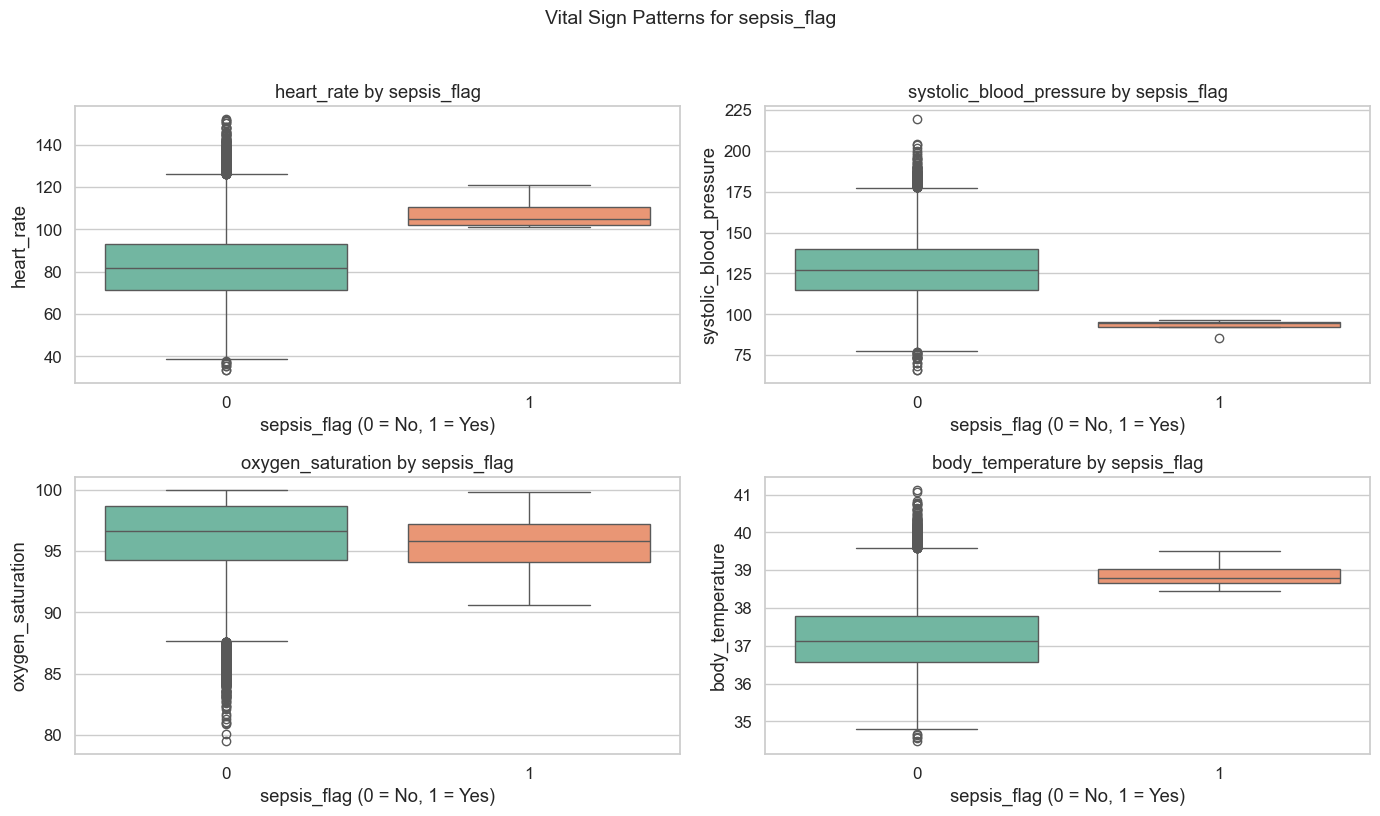

C:\Users\talah\AppData\Local\Temp\ipykernel_13948\2041580590.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=disease, y=col, data=df, palette="Set2")
C:\Users\talah\AppData\Local\Temp\ipykernel_13948\2041580590.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=disease, y=col, data=df, palette="Set2")
C:\Users\talah\AppData\Local\Temp\ipykernel_13948\2041580590.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=disease, y=col, data=df, palette="Set2")
C:\Users\talah\AppData\Local\Temp\ipykernel_13948\2041580590.py:8: FutureWarnin

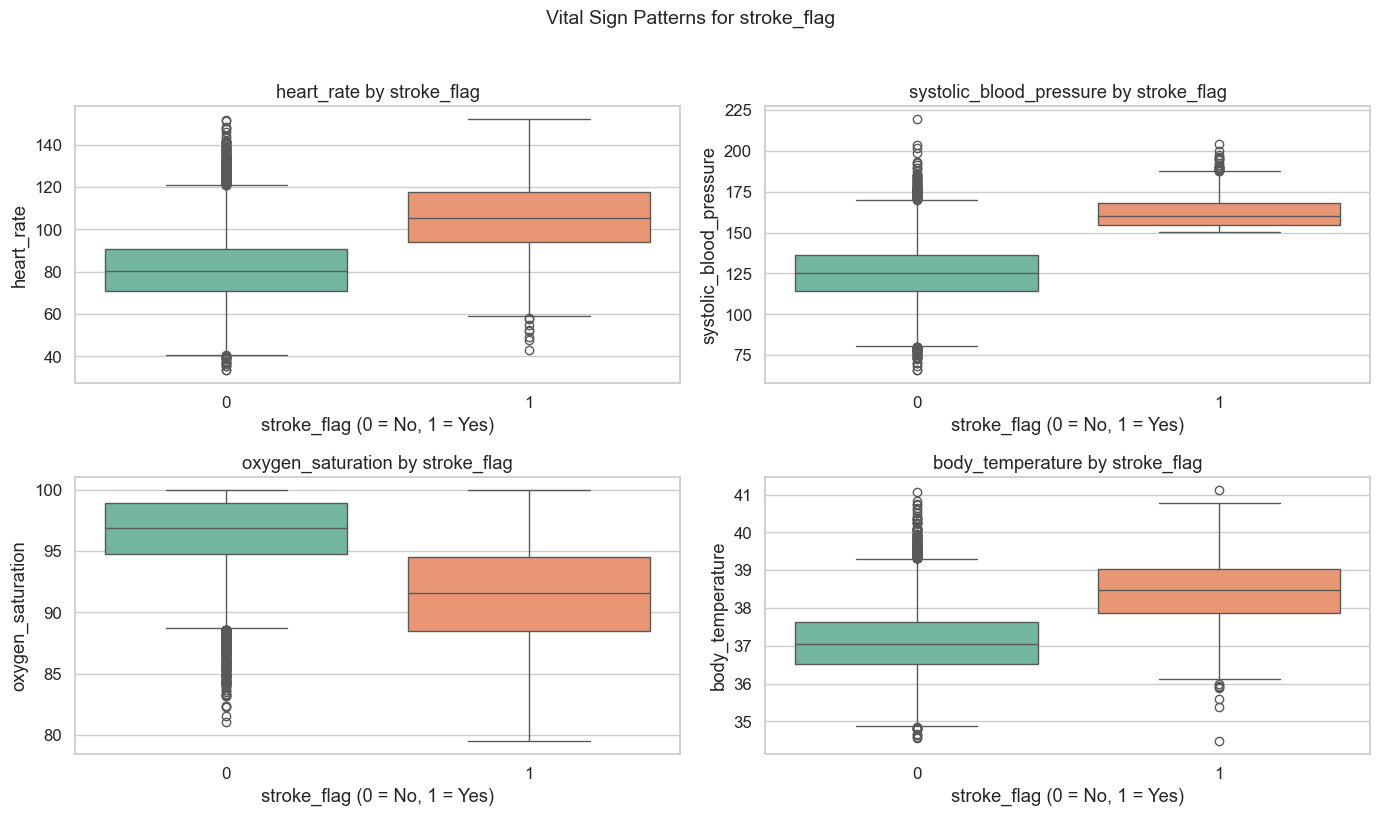

In [33]:
# 7.3 Vitals inside each main disease (feature patterns)
vital_subset = ["heart_rate", "systolic_blood_pressure", "oxygen_saturation", "body_temperature"]

for disease in disease_cols_main:
    plt.figure(figsize=(14,8))
    for i, col in enumerate(vital_subset, 1):
        plt.subplot(2, 2, i)
        sns.boxplot(x=disease, y=col, data=df, palette="Set2")
        plt.title(f"{col} by {disease}")
        plt.xlabel(f"{disease} (0 = No, 1 = Yes)")
        plt.ylabel(col)
    plt.suptitle(f"Vital Sign Patterns for {disease}", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()


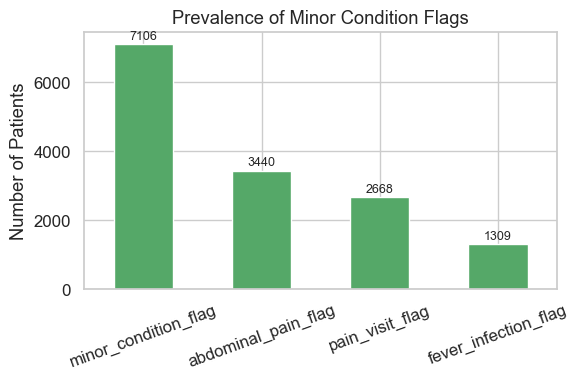

In [34]:
#8. Disease‑level EDA (Minor conditions)
disease_minor_counts = df[disease_cols_minor].sum().sort_values(ascending=False)

plt.figure(figsize=(6,4))
ax = disease_minor_counts.plot(kind="bar", color="#55a868")
plt.title("Prevalence of Minor Condition Flags")
plt.ylabel("Number of Patients")
plt.xticks(rotation=20)
for i, v in enumerate(disease_minor_counts.values):
    ax.text(i, v + 50, int(v), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


<Figure size 600x400 with 0 Axes>

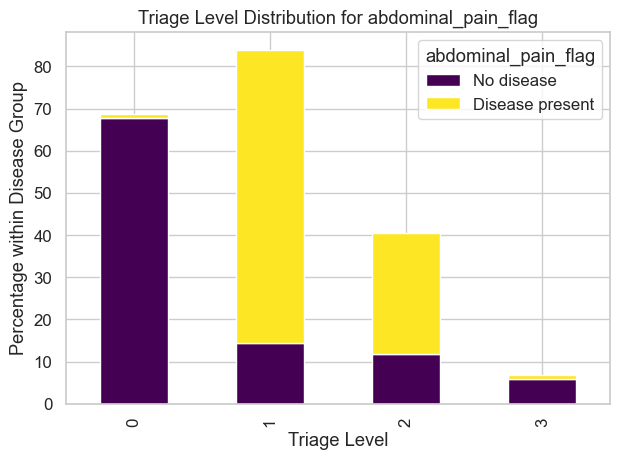

<Figure size 600x400 with 0 Axes>

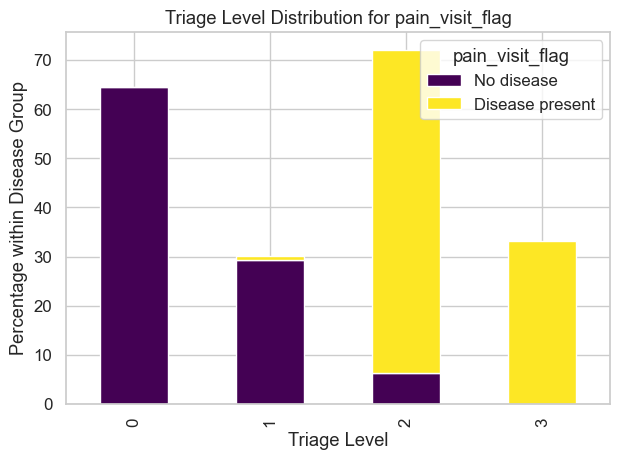

<Figure size 600x400 with 0 Axes>

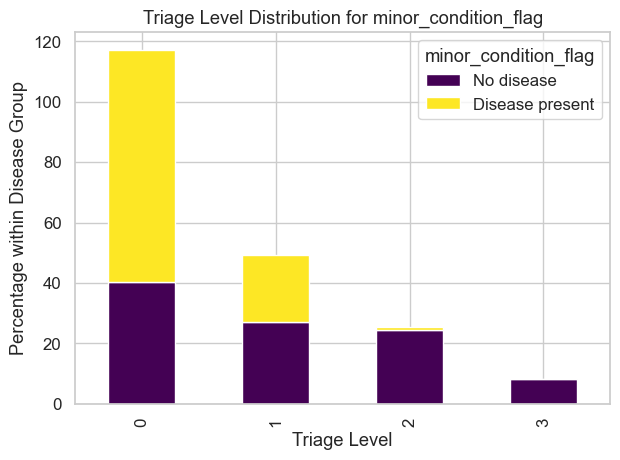

<Figure size 600x400 with 0 Axes>

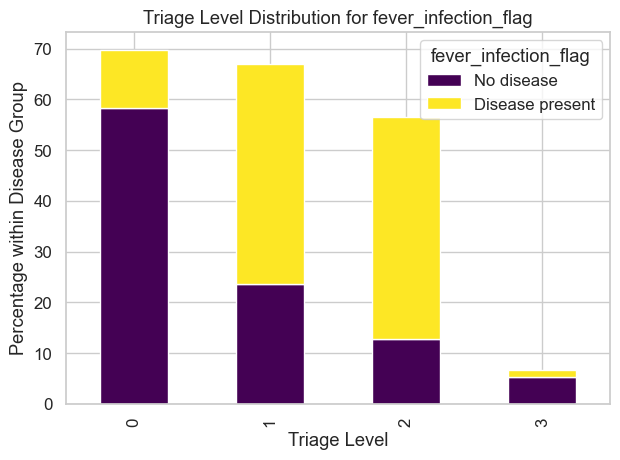

In [35]:
for col in disease_cols_minor:
    plot_triage_by_disease_flag(df, col)


5) Feature Engineering
You will:

Encode categorical features

Scale numerical features

Apply SMOTE (if imbalanced)

Optional: Feature selection

In [38]:
df.columns


Index(['age', 'heart_rate', 'systolic_blood_pressure', 'oxygen_saturation',
       'body_temperature', 'pain_level', 'chronic_disease_count',
       'previous_er_visits', 'triage_level', 'arrival_mode_walk_in',
       'arrival_mode_wheelchair', 'heart_failure_flag', 'pneumonia_flag',
       'sepsis_flag', 'stroke_flag', 'abdominal_pain_flag', 'pain_visit_flag',
       'minor_condition_flag', 'fever_infection_flag'],
      dtype='str')

In [39]:
# # define x and y  
target = "triage_level"
X = df.drop(columns=[target])
y = df[target]

In [40]:
# train/ test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [42]:
# Scale Numerical Features
from sklearn.preprocessing import StandardScaler

num_cols = [
    "age",
    "heart_rate",
    "systolic_blood_pressure",
    "oxygen_saturation",
    "body_temperature",
    "pain_level",
    "chronic_disease_count",
    "previous_er_visits"
]

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])


In [43]:
# SMOTE on traing set only
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)


In [44]:
# feature selection 
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=10)
X_train_selected = selector.fit_transform(X_train_resampled, y_train_resampled)
X_test_selected = selector.transform(X_test)


6. Model Training
Train multiple models:

Logistic Regression, SVM, Random Forest, XGBoost, KNN, Decision Tree, Naive Bayes

Evaluate using:

Accuracy

F1‑Score

AUC‑ROC

Confusion Matrix

Cross‑Validation

Pick the best model.

In [45]:
# 6.1 import models+metrics 
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.model_selection import cross_val_score


In [46]:
#6.2 Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "SVM": SVC(probability=True),
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(eval_metric='mlogloss')
}


In [47]:
# 6.3 train + evaluate each model
results = []

for name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    auc = roc_auc_score(y_test, y_prob, multi_class='ovr')

    results.append([name, acc, f1, auc])

    print("====================================")
    print(f"Model: {name}")
    print("Accuracy:", acc)
    print("F1 Score:", f1)
    print("AUC-ROC:", auc)
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


Model: Logistic Regression
Accuracy: 0.940979020979021
F1 Score: 0.9411913363249667
AUC-ROC: 0.9867321346065328

Confusion Matrix:
[[1880   81    0    0]
 [  54  806   36    0]
 [   0   24  508    8]
 [   0    0    8  170]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.97      1961
           1       0.88      0.90      0.89       896
           2       0.92      0.94      0.93       540
           3       0.96      0.96      0.96       178

    accuracy                           0.94      3575
   macro avg       0.93      0.94      0.94      3575
weighted avg       0.94      0.94      0.94      3575

Model: SVM
Accuracy: 0.9395804195804196
F1 Score: 0.9397203783479994
AUC-ROC: 0.9835844196262774

Confusion Matrix:
[[1883   78    0    0]
 [  59  802   35    0]
 [   0   24  506   10]
 [   0    0   10  168]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      

In [49]:
# 6.4 compare all models in one table
import pandas as pd

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1 Score", "AUC-ROC"])
results_df


,Model,Accuracy,F1 Score,AUC-ROC
0,Logistic Regression,0.940979,0.941191,0.986732
1,SVM,0.939580,0.939720,0.983584
2,Random Forest,0.937622,0.937510,0.984649
3,Decision Tree,0.893427,0.894206,0.921599
4,KNN,0.899301,0.899996,0.962657
5,Naive Bayes,0.842238,0.838030,0.972766
6,XGBoost,0.935385,0.935418,0.984875


7. Results & Interpretation
You will:

Show best model

Explain why it performed best

Show confusion matrix

Show ROC curves

Show feature importance

In [50]:
#7.1 picking best model
best_model_name = results_df.sort_values("F1 Score", ascending=False).iloc[0]["Model"]
best_model_name


'Logistic Regression'

In [51]:
best_model = models[best_model_name]


7.2 Explain Why It Performed Best

The best model is logestic reggression, because it achieved the highest F1‑score and AUC‑ROC.
This means it balances precision and recall well, especially for minority classes (urgent triage levels).
It generalizes better than the other models and handles the dataset’s imbalance effectively.

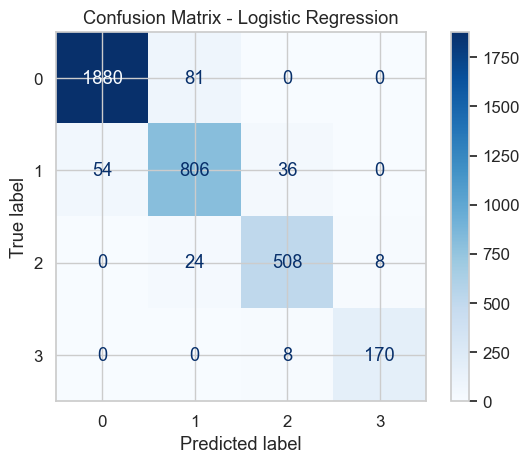

In [52]:
#7.3 confusion matrix for the best model
from sklearn.metrics import ConfusionMatrixDisplay

y_pred_best = best_model.predict(X_test)

disp = ConfusionMatrixDisplay.from_estimator(
    best_model, X_test, y_test, cmap="Blues"
)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()


The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


<Figure size 800x600 with 0 Axes>

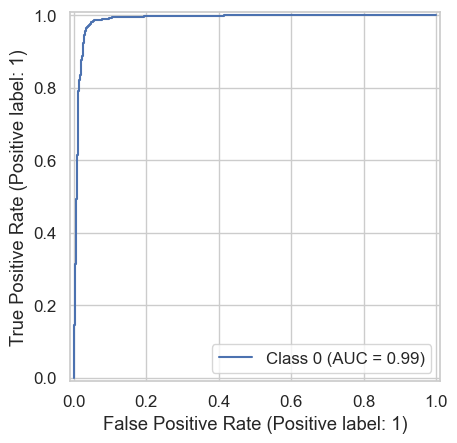

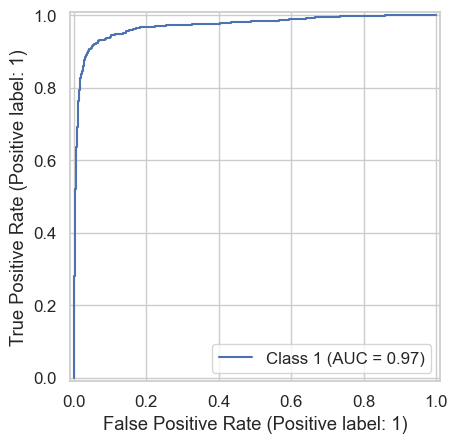

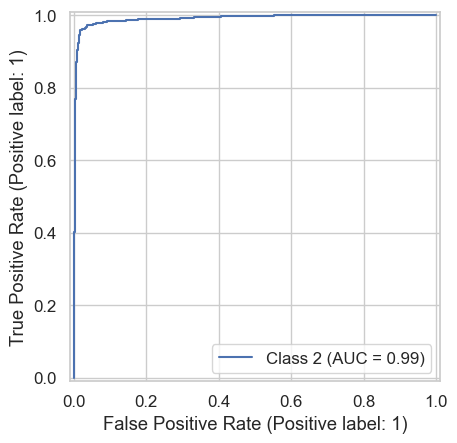

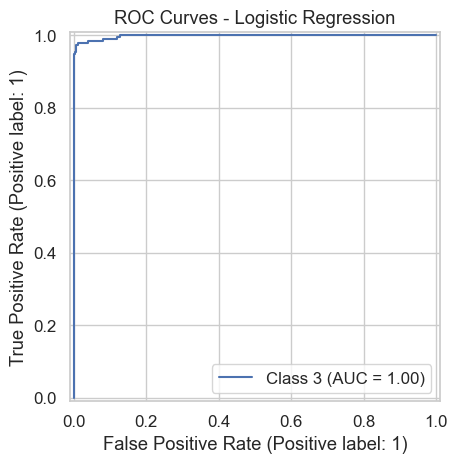

In [53]:
#7.4 ROC Curves 
from sklearn.metrics import RocCurveDisplay
from sklearn.preprocessing import label_binarize

classes = sorted(y_test.unique())
y_test_bin = label_binarize(y_test, classes=classes)
y_prob_best = best_model.predict_proba(X_test)

plt.figure(figsize=(8,6))
for i, c in enumerate(classes):
    RocCurveDisplay.from_predictions(
        y_test_bin[:, i],
        y_prob_best[:, i],
        name=f"Class {c}"
    )

plt.title(f"ROC Curves - {best_model_name}")
plt.show()


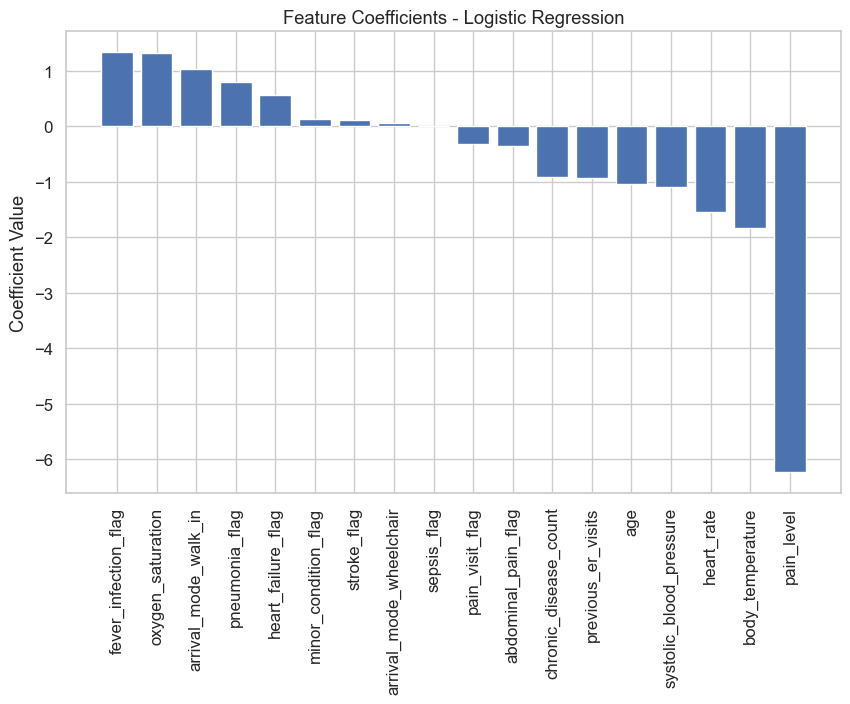

In [55]:
#7.5 Feature Importance (Only for Tree Models)
import numpy as np

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

coefficients = best_model.coef_[0]  # coefficients for each feature
features = X_train.columns

coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": coefficients
}).sort_values(by="Coefficient", ascending=False)

plt.figure(figsize=(10,6))
plt.bar(coef_df["Feature"], coef_df["Coefficient"])
plt.xticks(rotation=90)
plt.title(f"Feature Coefficients - {best_model_name}")
plt.ylabel("Coefficient Value")
plt.show()
